#Thyroid Classification System

##Importing Necessary Libraries

In [49]:
!pip install pycaret

In [50]:
!pip install joblib

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycaret.classification import *
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
#from sklearn.externals import joblib
import joblib
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Reading the Dataset

In [53]:
#df=pd.read_csv('Thyroid_Dataset.csv')
df=pd.read_csv('/content/drive/MyDrive/ProjectDatasets/Thyroid/Thyroid_Dataset.csv')

##Displaying the Data

In [54]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [55]:
print(df.columns)

Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')


##Data Size

In [56]:
df.shape

(383, 17)

##Checking Data Types

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

##Checking for Duplicate values

In [58]:
print(df.duplicated().sum())

19


In [59]:
df=df.drop_duplicates()

##Checking for Null Values

In [60]:
df.isnull().sum()

,0
Age,0
Gender,0
Smoking,0
Hx Smoking,0
Hx Radiothreapy,0
Thyroid Function,0
Physical Examination,0
Adenopathy,0
Pathology,0
Focality,0


##Checking unique values in each column

In [61]:
df.nunique()

,0
Age,65
Gender,2
Smoking,2
Hx Smoking,2
Hx Radiothreapy,2
Thyroid Function,5
Physical Examination,5
Adenopathy,6
Pathology,4
Focality,2


In [62]:
for col in df.columns:
    print(df[col].value_counts())
    print('--------')

Age
31    21
27    13
30    12
33    12
28    11
      ..
15     1
82     1
76     1
64     1
78     1
Name: count, Length: 65, dtype: int64
--------
Gender
F    293
M     71
Name: count, dtype: int64
--------
Smoking
No     315
Yes     49
Name: count, dtype: int64
--------
Hx Smoking
No     336
Yes     28
Name: count, dtype: int64
--------
Hx Radiothreapy
No     357
Yes      7
Name: count, dtype: int64
--------
Thyroid Function
Euthyroid                      313
Clinical Hyperthyroidism        20
Subclinical Hypothyroidism      14
Clinical Hypothyroidism         12
Subclinical Hyperthyroidism      5
Name: count, dtype: int64
--------
Physical Examination
Multinodular goiter            135
Single nodular goiter-right    127
Single nodular goiter-left      88
Normal                           7
Diffuse goiter                   7
Name: count, dtype: int64
--------
Adenopathy
No           258
Right         48
Bilateral     32
Left          17
Extensive      7
Posterior      2
Name: count, 

In [63]:
df.describe()

,Age
count,364.00000
mean,41.25000
std,15.31436
min,15.00000
25%,30.00000
50%,38.00000
75%,52.00000
max,82.00000


In [64]:
cat_cols=['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Stage']
num_cols=['Age']

Text(0.5, 0, 'Age')

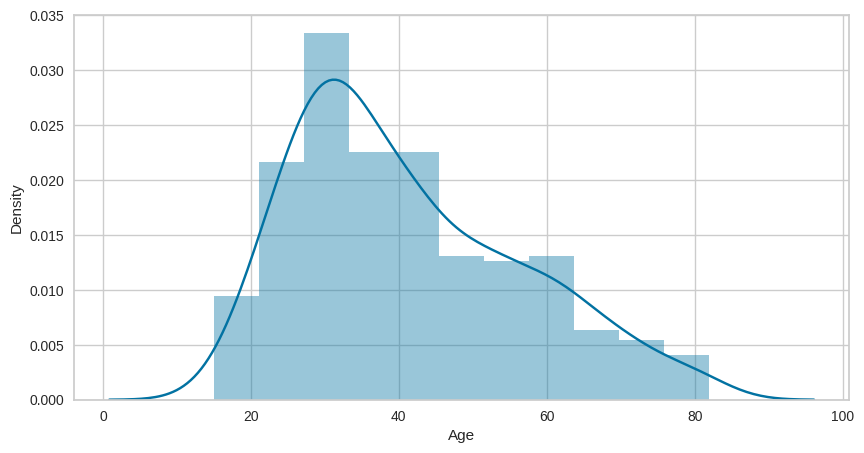

In [65]:
plt.figure(figsize=(10,5))
sns.distplot(df['Age'])
plt.xlabel('Age')

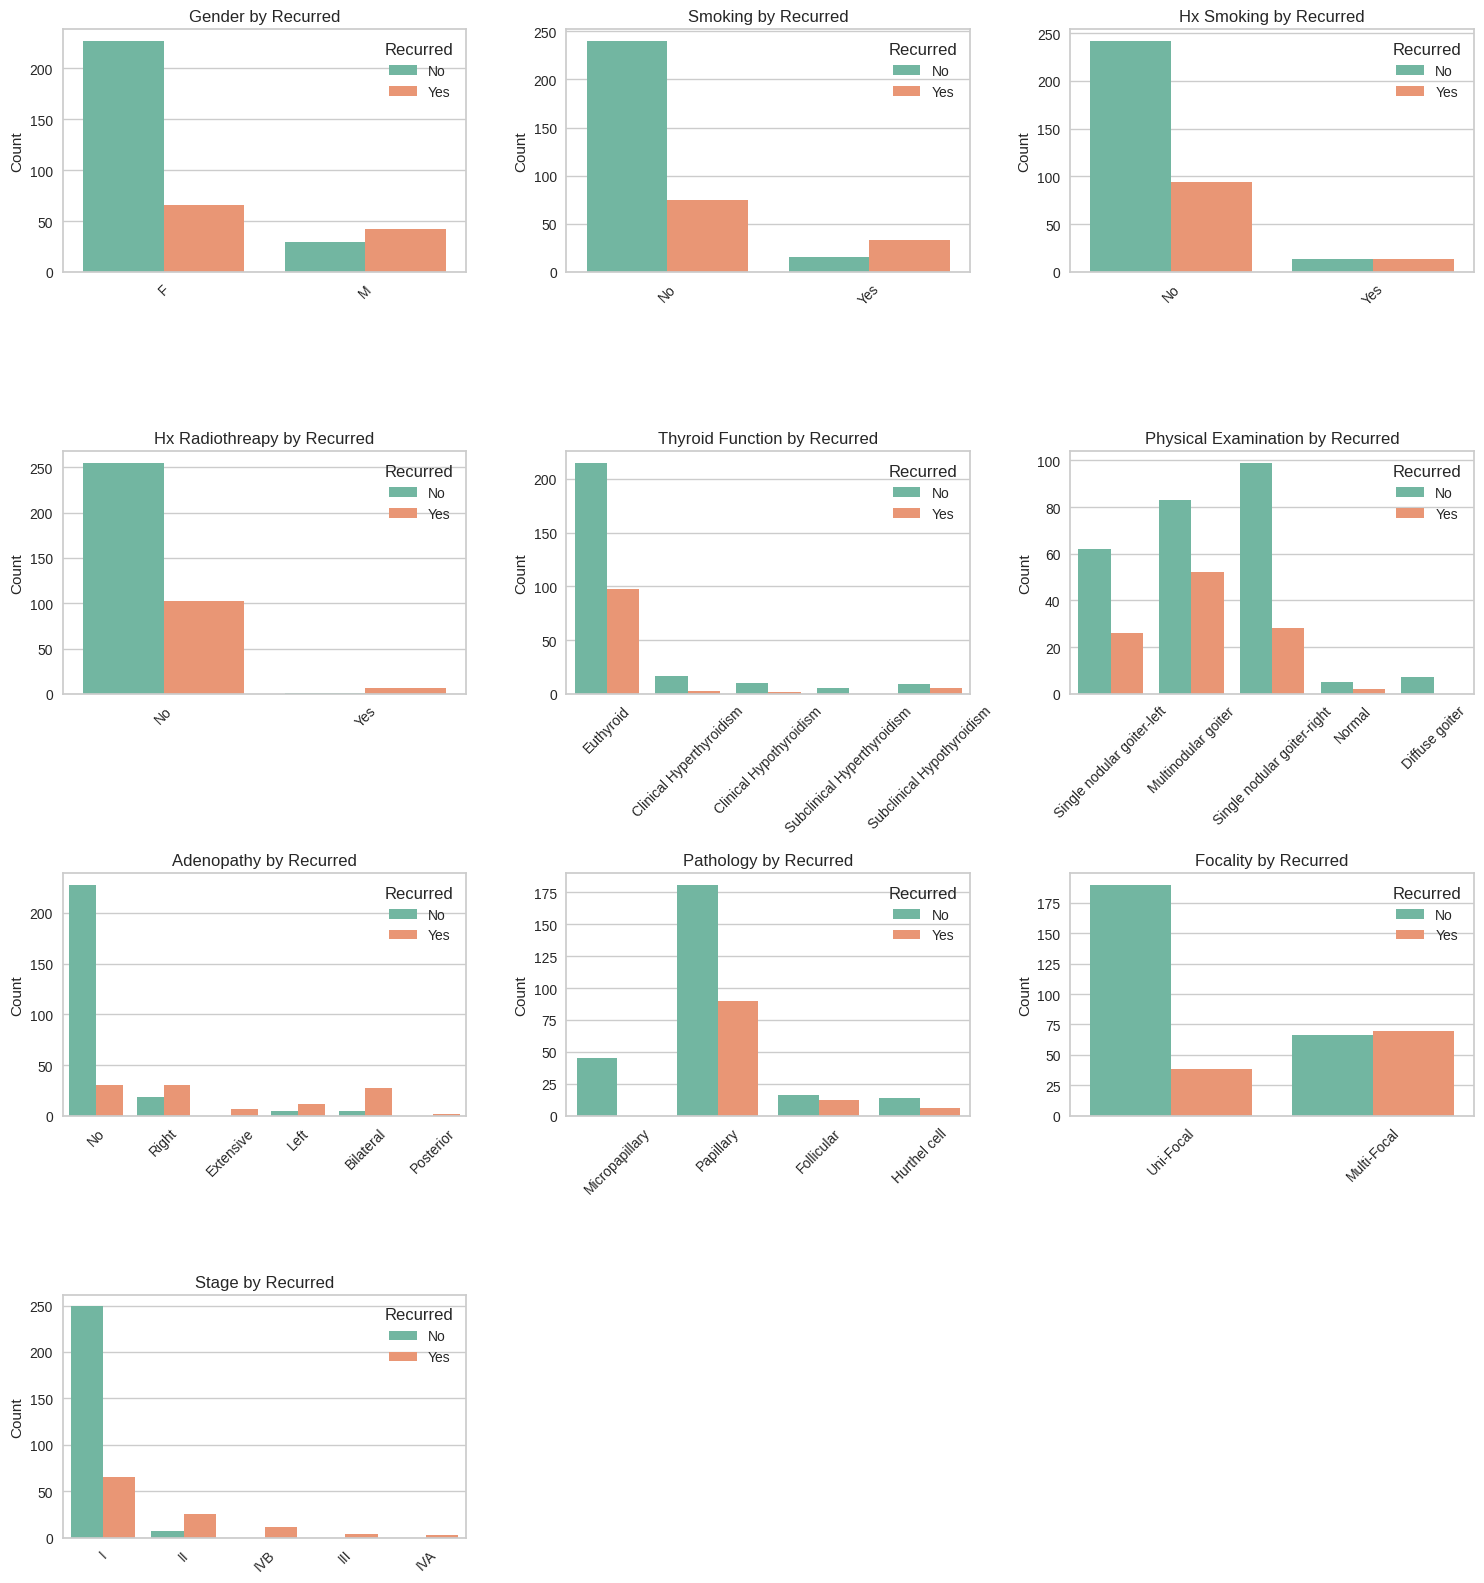

In [66]:
import math
n = len(cat_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=df, x=col, hue='Recurred', palette='Set2')
    plt.title(f'{col} by Recurred')
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [67]:
le=LabelEncoder()
scaler=StandardScaler()

In [68]:
fin_df=df.copy().drop(columns=['T','N','M'],axis=1)

In [69]:
fin_df['Risk'] = fin_df['Risk'].replace({
    'Intermediate': 'High'
})

In [70]:
fin_df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,I,Excellent,No


#Thyroid Risk Prediction

In [71]:
risk_pred_train=fin_df.drop(columns=['Recurred','Response'],axis=1)

In [72]:
risk_pred_train.columns

Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'Stage'],
      dtype='object')

In [73]:
risk_pred_train['Risk'].value_counts()

,count
Risk,
Low,230
High,134


In [74]:
# risk_pred_train['Age_bin'] = pd.cut(
#     risk_pred_train['Age'],
#     bins=[0, 30, 45, 60, 120],
#     labels=[0, 1, 2, 3]
# )

# # Drop original Age
# risk_pred_train = risk_pred_train.drop(columns=['Age'])

##Checking the best base model using Pycaret

In [75]:
clf = setup(
    data=risk_pred_train,
    target='Risk',
    session_id=42,
    normalize=False,
#     handle_unknown_categorical=True,
    fix_imbalance=True,
    fold=5
)

,Description,Value
0,Session id,42
1,Target,Risk
2,Target type,Binary
3,Target mapping,"High: 0, Low: 1"
4,Original data shape,"(364, 12)"
5,Transformed data shape,"(430, 32)"
6,Transformed train set shape,"(320, 32)"
7,Transformed test set shape,"(110, 32)"
8,Numeric features,1
9,Categorical features,10


In [76]:
best_models = compare_models(sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9213,0.9310,0.9213,0.9239,0.9202,0.8277,0.8321,0.2720
ridge,Ridge Classifier,0.9054,0.9311,0.9054,0.9079,0.9040,0.7921,0.7971,0.2180
lda,Linear Discriminant Analysis,0.8975,0.9269,0.8975,0.8999,0.8963,0.7760,0.7804,0.3180
nb,Naive Bayes,0.8859,0.9173,0.8859,0.8888,0.8823,0.7445,0.7529,0.3100
lightgbm,Light Gradient Boosting Machine,0.8856,0.9151,0.8856,0.8876,0.8845,0.7508,0.7547,0.2600
ada,Ada Boost Classifier,0.8820,0.9060,0.8820,0.8823,0.8811,0.7437,0.7456,0.3080
xgboost,Extreme Gradient Boosting,0.8818,0.9106,0.8818,0.8822,0.8808,0.7427,0.7449,0.1600
gbc,Gradient Boosting Classifier,0.8780,0.9213,0.8780,0.8795,0.8770,0.7349,0.7382,0.5080
rf,Random Forest Classifier,0.8779,0.8969,0.8779,0.8814,0.8759,0.7322,0.7387,0.5540
et,Extra Trees Classifier,0.8660,0.8671,0.8660,0.8694,0.8652,0.7107,0.7151,0.4500


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [77]:
risk_pred_train['Risk'] = risk_pred_train['Risk'].map({'Low': 0, 'High': 1})

In [78]:
risk_pred_train['Risk'] .value_counts()

,count
Risk,
0,230
1,134


##Encoding

In [79]:
label_encoders_risk = {}

for col in cat_cols:
    le = LabelEncoder()
    risk_pred_train[col] = le.fit_transform(risk_pred_train[col])
    label_encoders_risk[col] = le

In [80]:
risk_pred_train['Age'] = scaler.fit_transform(risk_pred_train[['Age']])

In [81]:
X = risk_pred_train.drop('Risk',axis=1)
y = risk_pred_train['Risk']

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [83]:
cat_cols=['Gender',
 'Smoking',
 'Hx Smoking',
 'Hx Radiothreapy',
 'Thyroid Function',
 'Physical Examination',
 'Adenopathy',
 'Pathology',
 'Focality',
 'Stage']

##Building the best model based on Pycaret results with hyperparameter tuning on Logistic Regression

In [84]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [85]:
log_reg.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)

In [86]:
y_pred = log_reg.predict(X_test)

In [87]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.821917808219178


In [88]:
joblib.dump(label_encoders_risk, 'label_encoders_risk.pkl')

['label_encoders_risk.pkl']

In [89]:
joblib.dump(X_train.columns.tolist(), 'feature_order_risk.pkl')

['feature_order_risk.pkl']

In [90]:
joblib.dump(log_reg, 'logistic_risk_model.pkl')

['logistic_risk_model.pkl']

In [91]:
joblib.dump(scaler, 'age_scaler_risk.pkl')

['age_scaler_risk.pkl']

##Model Predictions

In [92]:
label_encoders = joblib.load('label_encoders_risk.pkl')
feature_order = joblib.load('feature_order_risk.pkl')
model = joblib.load('logistic_risk_model.pkl')
scaler = joblib.load('age_scaler_risk.pkl')

In [93]:
#NO
custom_input = {
    'Age': 27,
    'Gender': 'F',
    'Smoking': 'No',
    'Hx Smoking': 'No',
    'Hx Radiothreapy': 'No',
    'Thyroid Function': 'Euthyroid',
    'Physical Examination': 'Single nodular goiter-left',
    'Adenopathy': 'No',
    'Pathology': 'Micropapillary',
    'Focality': 'Uni-Focal',
#     'Risk': 'Low',
    'Stage': 'I',
}

custom_df = pd.DataFrame([custom_input])

In [94]:

df = pd.DataFrame([custom_input])

for col, le in label_encoders.items():
    df[col] = le.transform(df[col])

df['Age'] = scaler.transform(df[['Age']])

df = df[feature_order]

pred = model.predict(df)[0]

result = 'High' if pred == 1 else 'Low'

print("Predicted Risk:", result)

Predicted Risk: Low


#Thyroid Recurrence Prediction

##Checking the best base model using Pycaret

In [95]:
clf = setup(
    data=fin_df,
    target='Recurred',
    session_id=42,
    normalize=False,
#     handle_unknown_categorical=True,
    fix_imbalance=True,
    fold=5
)

,Description,Value
0,Session id,42
1,Target,Recurred
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(364, 14)"
5,Transformed data shape,"(468, 37)"
6,Transformed train set shape,"(358, 37)"
7,Transformed test set shape,"(110, 37)"
8,Numeric features,1
9,Categorical features,12


In [96]:
best_models = compare_models(sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.9646,0.9722,0.9646,0.9667,0.9638,0.9115,0.9156,0.2100
gbc,Gradient Boosting Classifier,0.9646,0.9838,0.9646,0.9650,0.9646,0.9147,0.9153,0.2340
xgboost,Extreme Gradient Boosting,0.9646,0.9907,0.9646,0.9667,0.9636,0.9108,0.9153,0.2600
rf,Random Forest Classifier,0.9607,0.9894,0.9607,0.9608,0.9602,0.9032,0.9044,0.2800
et,Extra Trees Classifier,0.9567,0.9883,0.9567,0.9569,0.9562,0.8935,0.8950,0.3060
lightgbm,Light Gradient Boosting Machine,0.9567,0.9848,0.9567,0.9571,0.9561,0.8931,0.8950,0.2440
lr,Logistic Regression,0.9529,0.9792,0.9529,0.9540,0.9523,0.8846,0.8869,0.2000
dt,Decision Tree Classifier,0.9449,0.9299,0.9449,0.9447,0.9446,0.8664,0.8668,0.1300
ridge,Ridge Classifier,0.9410,0.9763,0.9410,0.9426,0.9404,0.8559,0.8589,0.1360
nb,Naive Bayes,0.9409,0.9586,0.9409,0.9424,0.9411,0.8590,0.8603,0.2160


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [97]:
recur_pred_train=fin_df.copy()

In [98]:
recur_pred_train['Recurred'] = recur_pred_train['Recurred'].map({'No': 0, 'Yes': 1})

In [99]:
cat_cols=['Gender',
 'Smoking',
 'Hx Smoking',
 'Hx Radiothreapy',
 'Thyroid Function',
 'Physical Examination',
 'Adenopathy',
 'Pathology',
 'Focality',
 'Stage','Risk','Response']

##Encoding

In [100]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    recur_pred_train[col] = le.fit_transform(recur_pred_train[col])
    label_encoders[col] = le

In [101]:
X = recur_pred_train.drop('Recurred',axis=1)
y = recur_pred_train['Recurred']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [103]:
import joblib
joblib.dump(label_encoders, 'label_encoders_recur.pkl')

['label_encoders_recur.pkl']

In [104]:
joblib.dump(X_train.columns.tolist(), 'feature_order_recur.pkl')

['feature_order_recur.pkl']

In [105]:
y.value_counts()

,count
Recurred,
0,256
1,108


In [106]:
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
scale_pos_weight

2.383720930232558

##Building the best model based on Pycaret results with hyperparameter tuning on XGBoost

In [107]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, objective='binary:logistic', ...)

In [108]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9315068493150684
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        51
           1       0.84      0.95      0.89        22

    accuracy                           0.93        73
   macro avg       0.91      0.94      0.92        73
weighted avg       0.94      0.93      0.93        73



In [109]:
joblib.dump(xgb_model, 'thyroid_xgb_recur.pkl')

['thyroid_xgb_recur.pkl']

##Model Prediction

In [110]:
#NO
custom_input = {
    'Age': 27,
    'Gender': 'F',
    'Smoking': 'No',
    'Hx Smoking': 'No',
    'Hx Radiothreapy': 'No',
    'Thyroid Function': 'Euthyroid',
    'Physical Examination': 'Single nodular goiter-left',
    'Adenopathy': 'No',
    'Pathology': 'Micropapillary',
    'Focality': 'Uni-Focal',
    'Risk': 'Low',
    'Stage': 'I',
    'Response':'Indeterminate'
}
#YES
custom_input = {
    'Age': 26,
    'Gender': 'F',
    'Smoking': 'No',
    'Hx Smoking': 'No',
    'Hx Radiothreapy': 'No',
    'Thyroid Function': 'Euthyroid',
    'Physical Examination': 'Normal',
    'Adenopathy': 'Extensive',
    'Pathology': 'Papillary',
    'Focality': 'Uni-Focal',
    'Risk': 'Intermediate',
    'Stage': 'I',
    'Response': 'Structural'
}
custom_df = pd.DataFrame([custom_input])

In [111]:
def encode_custom_input(df, label_encoders):
    df_encoded = df.copy()

    for col, le in label_encoders.items():
        if col in df_encoded.columns:
            df_encoded[col] = df_encoded[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    return df_encoded

custom_df_encoded = encode_custom_input(custom_df, label_encoders)

In [112]:
prediction = xgb_model.predict(custom_df_encoded)

print("Prediction:", "Yes" if prediction[0] == 1 else "No")

Prediction: Yes


In [1]:
import joblib

# Save your trained model
joblib.dump(model, "thyroid_model.pkl")

# Save your scaler (if you used StandardScaler)
joblib.dump(scaler, "scaler.pkl")

print("Saved!")

NameError: name 'model' is not defined